In [1]:
import sys
import os

import json
import random
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import yaml
import cv2
from datasets.fmd.data_loader import load_noisy_single_loader
from QUTCC_eval import create_broken_axis_pdf_plot
from evaluation import get_largest_residual_indices
from evaluation.calibration_utils import (AnalysisManager, CalibrationManager,
                                          get_test_dataloader)
from models.checkpointing import load_checkpoint_for_inference, create_model, load_model_state
from QUTCC_eval import plot_visualization

np.random.seed(0)
random.seed(0)
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print("tmp folder: ", os.environ["TMPDIR"])

%matplotlib inline
%load_ext autoreload
%autoreload 2

/home/ty392/.conda/envs/qutcc/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Device: cuda
tmp folder:  /tmp


In [2]:
with open('QUTCC_eval/params.yml', 'r') as file:
    params = yaml.safe_load(file)

experiment_name = 'QPI'  #Options: 'Gaussian', 'Poisson', 'Real-Noise', 'MRI', 'QPI'
config = params[experiment_name]

In [3]:
#Load in weights + calibration values
im2im_deep_path = config['im2im_weight_path']
qutcc_path = config['quantile_weight_path']

# #Pre-calibrated values:
im2im_deep_lambda = config['im2im_deep_lambda']
upper_q = config['upper_q']
lower_q = config['lower_q']
quantile_levels = config['quantile_levels']
quantile_levels_conformal = config['quantile_levels_conformal']

# #Load in clean/noisy image + tuned model checkpoint
if experiment_name == "QPI":
    noisy1 = torch.tensor(cv2.imread(config['noisy_img_1'], cv2.IMREAD_GRAYSCALE).astype(np.float32))
    noisy2 = torch.tensor(cv2.imread(config['noisy_img_2'], cv2.IMREAD_GRAYSCALE).astype(np.float32))
    noisy = torch.stack([noisy1, noisy2])
    ground_truth = torch.tensor(cv2.imread(config['clean_img'], cv2.IMREAD_GRAYSCALE).astype(np.float32)).unsqueeze(0)
    ground_truth = ground_truth.repeat(2, 1, 1)
    
    im2im_deep = create_model(net = "unet_im2im",in_channels = 2, device = device)
    im2im_deep = load_model_state(im2im_deep, im2im_deep_path, device)
    
    qutcc = create_model(net = "unet_quantile", in_channels = 2, device = device)
    qutcc = load_model_state(qutcc, qutcc_path, device)

else:
    noisy = torch.tensor(cv2.imread(config['noisy_img'], cv2.IMREAD_GRAYSCALE).astype(np.float32))
    ground_truth = torch.tensor(cv2.imread(config['clean_img'], cv2.IMREAD_GRAYSCALE).astype(np.float32))

    im2im_deep = create_model(net = "unet_im2im", device = device)
    im2im_deep = load_model_state(im2im_deep, im2im_deep_path, device)
    
    qutcc = create_model(net = "unet_quantile", device = device)
    qutcc = load_model_state(qutcc, qutcc_path, device)


Model state loaded from ./QUTCC_eval/weights/qpi_unet_im2im.pth
Model state loaded from ./QUTCC_eval/weights/qpi_quantile.pth


In [4]:
test = noisy.unsqueeze(0)
print(test.shape)

torch.Size([1, 2, 128, 128])


img is shape =  (128, 128, 1)
img is shape =  (128, 128, 1)
img is shape =  (128, 128, 2)
img is shape =  (128, 128, 1)
img is shape =  (128, 128, 2)
img is shape =  (128, 128, 1)
img is shape =  (128, 128, 2)
img is shape =  (128, 128, 1)


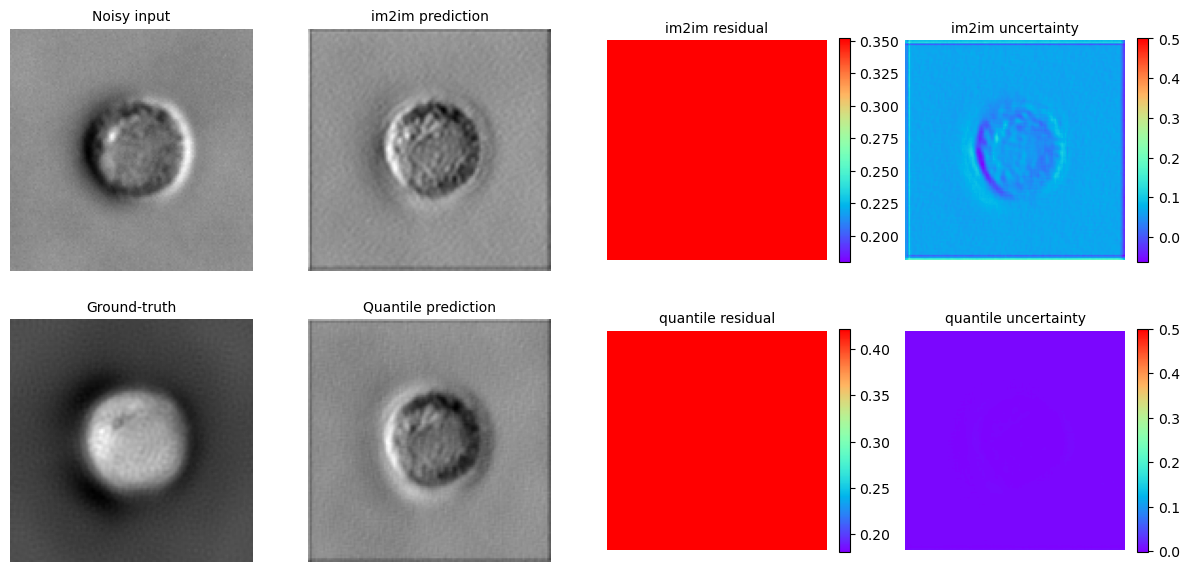

In [5]:
#Visualization
fig, ax = plot_visualization(noisy.unsqueeze(0), ground_truth.unsqueeze(0), im2im_model=im2im_deep, 
                    quantile_model=qutcc, im2im_lam=im2im_deep_lambda, lower_q=lower_q, upper_q=upper_q, 
                    device=device, residual_vmax=0.2, uncertainty_vmax=0.5, exp_type= experiment_name, save=False)
plt.show()

In [ ]:
fig = create_broken_axis_pdf_plot(
        quantile_model=qutcc,
        noisy_tensor=noisy,
        quantile_levels=quantile_levels,
        quantile_levels_conformal=quantile_levels_conformal,
        device=device,
        pixel_coords=[(100, 102), (431, 400)],
        xlim_left=(0.05, 0.105),
        xlim_right=(0.11, 0.36),
        ylim=(0, 80),
        figsize=(14, 6)
    )
plt.show()